In [23]:
# DOWNLOAD DATASET FROM KAGGLE USING KAGGLE API
# ENSURE KAGGLE IS DOWNLOADED WITH "pip install kaggle"
# ENSURE "kaggle.json" AUTHENTICATION IS LOCATED IN "~/.kaggle" FOLDER

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

api.dataset_download_files('fedesoriano/heart-failure-prediction', path='./', unzip=True)
path = "./heart.csv"


Dataset URL: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction


In [24]:
# IMPORT LIBRARIES
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv(path) # load csv as pandas dataframe
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [26]:
# check for missing values
print("Columns With Missing Values:")
print(df.isnull().any())
print("-------------------")


# present number of positive and negative cases
print("Positive and Negative Cases for Prevalence of Heart Disease:")
pos_count = df["HeartDisease"].value_counts()[1]
neg_count = df["HeartDisease"].value_counts()[0]

print("There are {} positive cases and {} negative cases for heart disease in this dataset"
      .format(pos_count, neg_count))
print("-------------------")

Columns With Missing Values:
Age               False
Sex               False
ChestPainType     False
RestingBP         False
Cholesterol       False
FastingBS         False
RestingECG        False
MaxHR             False
ExerciseAngina    False
Oldpeak           False
ST_Slope          False
HeartDisease      False
dtype: bool
-------------------
Positive and Negative Cases for Prevalence of Heart Disease:
There are 508 positive cases and 410 negative cases for heart disease in this dataset
-------------------


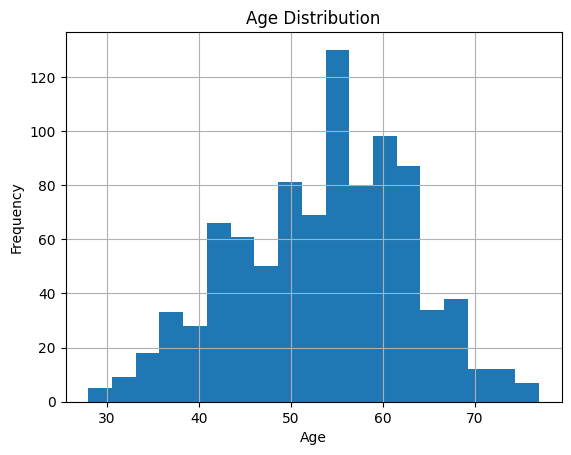

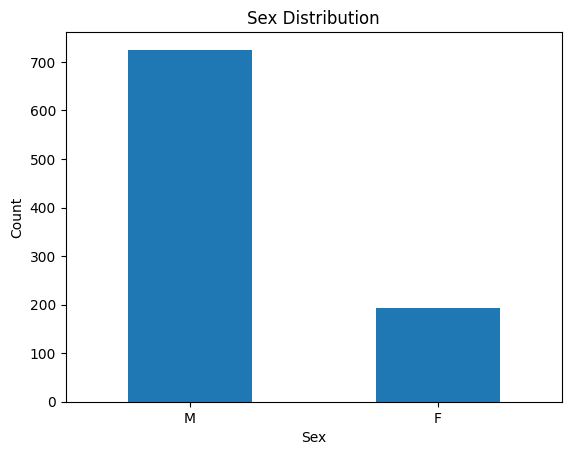

In [27]:
# plot age distribution and sex distribution 
df["Age"].hist(bins="auto")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

df["Sex"].value_counts().plot(kind="bar")
plt.title("Sex Distribution")
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Keep x-labels horizontal
plt.show()

In [28]:
# encode string valued columns to numerical values for easier processing
df_numerical = df.copy()
df_numerical['Sex'] = df_numerical['Sex'].map({'M': 1, 'F': 0})
df_numerical['ExerciseAngina'] = df_numerical['ExerciseAngina'].map({'Y': 1, 'N': 0})

# dummy-encoding for columns with multiple (more than 2) string options
df_numerical = pd.get_dummies(df_numerical, 
                    columns=['ChestPainType', 'RestingECG', 'ST_Slope'],
                    drop_first=True)

# move HeartDisease (target column) to the end
df_numerical = df_numerical[[c for c in df_numerical.columns if c != "HeartDisease"] + ["HeartDisease"]]

Text(0.5, 1.0, 'Correlation Matrix of Features (Including Target: Prevelance of Heart Disease)')

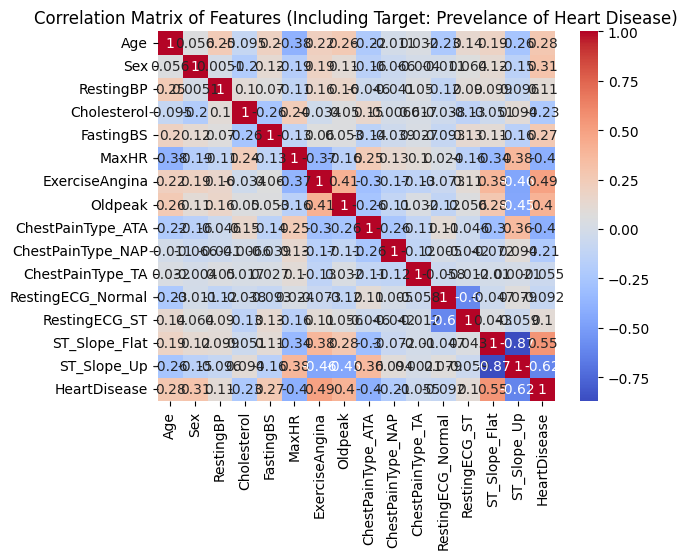

In [29]:
# plot correlation heatmap 
sns.heatmap(df_numerical.corr(), annot=True, cmap="coolwarm") # plot correlation matrix with seaborn (sns)
plt.title("Correlation Matrix of Features (Including Target: Prevelance of Heart Disease)")

In [30]:
# SPLIT THE DATA INTO TRAINING AND TESTING SETS

from sklearn.model_selection import train_test_split

X = df_numerical.drop("HeartDisease", axis=1)
y = df_numerical["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size - ", "X: ", X_train.shape, "y: ", y_train.shape)
print("Test set size - ", "X: ", X_test.shape, "y: ", y_test.shape)

Training set size -  X:  (734, 15) y:  (734,)
Test set size -  X:  (184, 15) y:  (184,)


In [31]:
# NORMALIZE NUMERICAL DATA

from sklearn.preprocessing import StandardScaler

numerical_column_names = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
scaler = StandardScaler()
scaler.fit(X_train[numerical_column_names])

# transform training and test data sets
X_train[numerical_column_names] = scaler.transform(X_train[numerical_column_names])
X_test[numerical_column_names]  = scaler.transform(X_test[numerical_column_names])

print("Normalized X train and test data")
X_train.head()


Normalized X train and test data


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
795,-1.245067,1,-0.708985,0.372803,1,2.284353,0,-0.097061,False,True,False,True,False,False,False
25,-1.886236,1,-0.166285,0.086146,0,1.652241,0,-0.836286,False,True,False,True,False,False,True
84,0.250993,1,0.919115,0.123134,1,-0.441628,1,0.087745,False,False,False,True,False,True,False
10,-1.779375,0,-0.166285,0.104640,0,0.229991,0,-0.836286,False,True,False,True,False,False,True
344,-0.283314,1,-0.708985,-1.846478,1,-1.271274,0,-0.836286,False,False,False,True,False,True,False


In [32]:
    """
    Calculate classification metrics based on true and predicted labels.

    Parameters:
    - y_true: Array of true labels (0 or 1).
    - y_pred: Array of predicted labels (0 or 1).

    Returns:
    - Accuracy: Ratio of correct predictions to total samples.
    - Precision: Accuracy of positive predictions among all predicted positives.
    - Recall: Ability to capture actual positives among all actual positives.
    - F1 Score: Harmonic mean of precision and recall, balancing both metrics.
    - FNR: Proportion of actual positives incorrectly predicted as negatives.
    """

def classification_performance_report(y_true, y_pred):
        true_pos_count = np.count_nonzero(y_true) # number of true positives
        pred_pos_count = np.count_nonzero(y_pred) # number of predicted positives
        
        pred_neg_count = len(y_pred) - pred_pos_count # number of predicted negatives
        
        false_pos_count = 0 # counter of false positive predictions
        false_neg_count = 0 # counter of false negative predictions
        
        for i in range(len(y_true)): # forloop to count false positives and negatives
            if y_pred[i] == 1: false_pos_count += 1 if y_true[i] != y_pred[i] else 0
            if y_pred[i] == 0: false_neg_count += 1 if y_true[i] != y_pred[i] else 0
            
        correct_pos_count = pred_pos_count - false_pos_count # number of correctly predicted positives
        correct_neg_count = pred_neg_count - false_neg_count # number of correctly predicted negatives
        
        Accuracy = (correct_pos_count + correct_neg_count) / len(y_pred) # accuracy = correctly predicted values / total
        Precision = correct_pos_count / pred_pos_count # percision = actual positives / predicted positives
        Recall = correct_pos_count / true_pos_count
        F1score = (2*Precision*Recall) / (Precision+Recall)
        FNR = false_neg_count / true_pos_count
        
        
        result = {
            'Accuracy:' : Accuracy,
            'Precision:' : Precision,
            'Recall:' : Recall,
            'F1score:': F1score,
            'FNR:': FNR
        
        }
        
        return result


In [33]:
# TRAIN LOGISTIC REGRESSION MODEL
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42) # create/define the model

lr_model.fit(X_train, y_train) # train the model
y_predicted = lr_model.predict(X_test) # test the model

print(classification_performance_report(y_test.to_numpy(), y_predicted))

{'Accuracy:': 0.8532608695652174, 'Precision:': 0.9, 'Recall:': 0.8411214953271028, 'F1score:': 0.8695652173913043, 'FNR:': 0.1588785046728972}


In [34]:
# TRAIN KNN MODEL
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5) # create/define the model

knn_model.fit(X_train, y_train) # train the model 
y_predicted = knn_model.predict(X_test) # test the model

print(classification_performance_report(y_test.to_numpy(), y_predicted))

{'Accuracy:': 0.8315217391304348, 'Precision:': 0.8584905660377359, 'Recall:': 0.8504672897196262, 'F1score:': 0.8544600938967136, 'FNR:': 0.14953271028037382}
